In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 定義所有標的
tickers = {
    # === 共同三家基礎標的 ===
    '2330.TW': '台積電（電子權值）',  
    '2881.TW': '富邦金（金融保險）',  
    '1216.TW': '統一（食品內需）',    # 建議用統一，防禦性比台塑化更好，能讓基礎前緣更漂亮

    # === 個別第四家標的 (全部改為台灣上市個股) ===
    '2412.TW': '中華電信（廖國宏 - 防禦/降風險）',      
    '2382.TW': '廣達（王俊達 - 動能/高報酬）',       
    '2603.TW': '長榮（呂旼 - 景氣循環/低相關）',    
}

# 抓取月資料 2020–2024
raw = yf.download(
    list(tickers.keys()),
    start='2020-01-01',
    end='2024-12-31',
    interval='1mo',
    auto_adjust=True
)['Close']

print(raw.shape)
print(raw.head())

[*********************100%***********************]  6 of 6 completed

(60, 6)
Ticker        1216.TW     2330.TW    2382.TW    2412.TW    2603.TW    2881.TW
Date                                                                         
2020-01-01  57.647388  282.595001  44.318138  86.076637  10.872495  27.014330
2020-02-01  58.123814  279.062469  44.318138  86.076637  10.687432  26.654535
2020-03-01  52.089100  241.971909  43.031483  85.678131   8.559199  22.516933
2020-04-01  55.185867  271.517395  46.391083  87.272148  10.271039  25.365280
2020-05-01  57.806206  260.371460  50.036606  88.069145  10.085975  25.425245


In [27]:
# 計算簡單報酬率
returns = raw.pct_change().dropna()

print(f"報酬率資料筆數：{returns.shape}")
print(returns.head())

報酬率資料筆數：(59, 6)
Ticker       1216.TW   2330.TW   2382.TW   2412.TW   2603.TW   2881.TW
Date                                                                  
2020-02-01  0.008264 -0.012500  0.000000  0.000000 -0.017021 -0.013319
2020-03-01 -0.103825 -0.132911 -0.029032 -0.004630 -0.199134 -0.155231
2020-04-01  0.059451  0.122103  0.078073  0.018605  0.200000  0.126498
2020-05-01  0.047482 -0.041051  0.078582  0.009132 -0.018018  0.002364
2020-06-01 -0.020604  0.071918  0.014286  0.058824 -0.013762  0.035377


In [28]:
# 平均報酬率與標準差
mean_returns = returns.mean()
std_returns = returns.std()
cov_matrix = returns.cov()


print("=== 月平均報酬率 ===")
print(mean_returns.round(4))
print("\n=== 月標準差 ===")
print(std_returns.round(4))
print("\n=== 共變異數矩陣 ===")
print(cov_matrix.round(6))
assets_3   = ['2330.TW', '2881.TW', '1216.TW']
assets_you = ['2330.TW', '2881.TW', '1216.TW', '2412.TW']
assets_A   = ['2330.TW', '2881.TW', '1216.TW', '2382.TW']
assets_B   = ['2330.TW', '2881.TW', '1216.TW', '2603.TW']


=== 月平均報酬率 ===
Ticker
1216.TW    0.0059
2330.TW    0.0262
2382.TW    0.0381
2412.TW    0.0059
2603.TW    0.0814
2881.TW    0.0217
dtype: float64

=== 月標準差 ===
Ticker
1216.TW    0.0406
2330.TW    0.0901
2382.TW    0.1266
2412.TW    0.0291
2603.TW    0.2790
2881.TW    0.0688
dtype: float64

=== 共變異數矩陣 ===
Ticker    1216.TW   2330.TW   2382.TW   2412.TW   2603.TW   2881.TW
Ticker                                                             
1216.TW  0.001650  0.000658  0.001063  0.000074  0.000700  0.000610
2330.TW  0.000658  0.008120  0.003266 -0.000134  0.003078  0.002112
2382.TW  0.001063  0.003266  0.016019 -0.000022  0.007803  0.001011
2412.TW  0.000074 -0.000134 -0.000022  0.000850  0.003254  0.000510
2603.TW  0.000700  0.003078  0.007803  0.003254  0.077847  0.007243
2881.TW  0.000610  0.002112  0.001011  0.000510  0.007243  0.004730


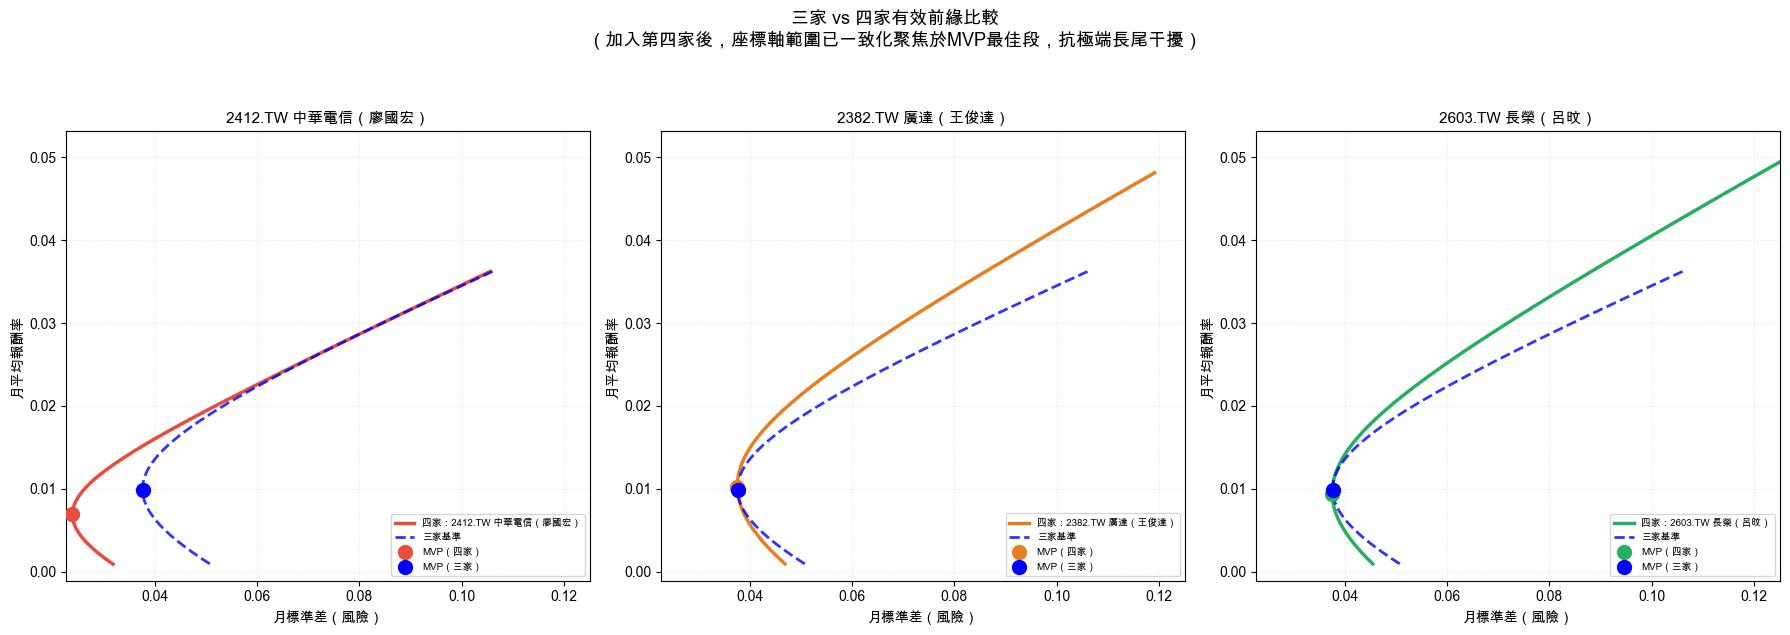

In [29]:
# 統一繪製效率前緣（允許放空，產生完美拋物線）
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

def portfolio_stats(weights, mean_ret, cov_mat):
    port_return = np.dot(weights, mean_ret)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    return port_return, port_std

def min_variance(target_return, mean_ret, cov_mat, x0=None):
    n = len(mean_ret)
    if x0 is None:
        x0 = np.ones(n) / n
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mean_ret) - target_return}
    ]
    bounds = [(None, None)] * n  # 允許無限放空
    result = minimize(
        lambda w: np.dot(w.T, np.dot(cov_mat, w)),
        x0=x0, bounds=bounds, constraints=constraints,
        method='SLSQP', tol=1e-9  # 提高計算精度以減少數值波動誤差
    )
    return result

def get_frontier(assets, n_points=300):
    mean_ret = mean_returns[assets]
    cov_mat = cov_matrix.loc[assets, assets]
    
    # 為了畫出明顯的拋物線，將報酬率範圍向上下延伸
    min_r = mean_ret.min() - 0.005
    max_r = mean_ret.max() + 0.010
    target_returns = np.linspace(min_r, max_r, n_points)
    
    frontier_std, frontier_ret = [], []
    n = len(mean_ret)
    current_x0 = np.ones(n) / n
    for tr in target_returns:
        res = min_variance(tr, mean_ret, cov_mat, current_x0)
        if res.success:
            _, std = portfolio_stats(res.x, mean_ret, cov_mat)
            frontier_std.append(std)
            frontier_ret.append(tr)
            current_x0 = res.x
            
    # ------ 新增平滑化處理 ------
    # 透過多項式擬合消除 scipy.optimize 數值最佳化的微小計算誤差(鋸齒狀)
    frontier_std = np.array(frontier_std)
    frontier_ret = np.array(frontier_ret)
    
    # 變異數 = 標準差的平方
    frontier_var = frontier_std ** 2
    
    # 擬合: var = a * ret^2 + b * ret + c
    coeffs = np.polyfit(frontier_ret, frontier_var, 2)
    
    # 產生完美平滑的曲線
    smooth_ret = np.linspace(min_r, max_r, n_points)
    smooth_var = np.polyval(coeffs, smooth_ret)
    
    # 計算標準差 (避免因為極小誤差導致負值)
    smooth_var = np.maximum(smooth_var, 0)
    smooth_std = np.sqrt(smooth_var)
    
    return smooth_std, smooth_ret

std_3,   ret_3   = get_frontier(assets_3)
std_you, ret_you = get_frontier(assets_you)
std_A,   ret_A   = get_frontier(assets_A)
std_B,   ret_B   = get_frontier(assets_B)

# ================= 新增：計算全局的最適合 xy 軸範圍 =================
# X/Y 軸的底邊界：必須要能顯示所有最低風險、最低報酬的 MVP 點核心
global_xmin = min([std_3.min(), std_you.min(), std_A.min(), std_B.min()]) * 0.95
global_ymin = min([ret_3.min(), ret_you.min(), ret_A.min(), ret_B.min()]) - 0.002

# X/Y 軸的頂邊界：我們以「三家基準」為主要框架，並剔除四家擴充組合中的「最大離群值」（如長榮過於極端的尾部）。
# 取次高值或基準值來作為畫布尺寸上限，避免視覺被壓縮成直線。
max_stds = sorted([std_3.max(), std_you.max(), std_A.max(), std_B.max()])
global_xmax = max([std_3.max(), max_stds[-2]]) * 1.05

max_rets = sorted([ret_3.max(), ret_you.max(), ret_A.max(), ret_B.max()])
global_ymax = max([ret_3.max(), max_rets[-2]]) + 0.005
# =================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs = [
    (std_you, ret_you, '2412.TW 中華電信（廖國宏）', '#e74c3c'),
    (std_A,   ret_A,   '2382.TW 廣達（王俊達）', '#e67e22'),
    (std_B,   ret_B,   '2603.TW 長榮（呂旼）', '#27ae60'),
]

for ax, (std_4, ret_4, label, color) in zip(axes, configs):
    ax.plot(std_4, ret_4, color=color, label=f'四家：{label}', linewidth=2.5)
    ax.plot(std_3, ret_3, 'b--', label='三家基準', linewidth=2, alpha=0.8)
    
    min4_idx = np.argmin(std_4)
    min3_idx = np.argmin(std_3)
    ax.scatter(std_4[min4_idx], ret_4[min4_idx], color=color, s=100, zorder=5, label='MVP（四家）')
    ax.scatter(std_3[min3_idx], ret_3[min3_idx], color='blue', s=100, zorder=5, label='MVP（三家）')
    
    # 🌟 統一設定相同的 x, y 軸合理範圍，抗離群極端值干擾
    ax.set_xlim(global_xmin, global_xmax)
    ax.set_ylim(global_ymin, global_ymax)
    
    ax.set_xlabel('月標準差（風險）', fontsize=10)
    ax.set_ylabel('月平均報酬率', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle=':')

plt.suptitle('三家 vs 四家有效前緣比較\n（加入第四家後，座標軸範圍已一致化聚焦於MVP最佳段，抗極端長尾干擾）',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('efficient_frontier_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
def get_mvp(mean_ret, cov_mat):
    n = len(mean_ret)
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(None, None)] * n
    result = minimize(
        lambda w: np.dot(w.T, np.dot(cov_mat, w)),
        x0=np.ones(n)/n,
        bounds=bounds,
        constraints=constraints
    )
    w = result.x
    ret = np.dot(w, mean_ret)
    std = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    return w, ret, std

w3, ret3, std3 = get_mvp(mean_returns[assets_3], cov_matrix.loc[assets_3, assets_3])
w_you, ret_you_mvp, std_you_mvp = get_mvp(mean_returns[assets_you], cov_matrix.loc[assets_you, assets_you])
w_A,   ret_A_mvp,   std_A_mvp   = get_mvp(mean_returns[assets_A],   cov_matrix.loc[assets_A,   assets_A])
w_B,   ret_B_mvp,   std_B_mvp   = get_mvp(mean_returns[assets_B],   cov_matrix.loc[assets_B,   assets_B])

print("=== 三家基準 MVP ===")
print(f"月報酬率：{ret3:.4f}，月標準差：{std3:.4f}")
print(f"權重：{dict(zip(assets_3, w3.round(4)))}")

print("\n=== 四家 MVP 比較 ===")
configs_mvp = [
    ('廖國宏（2412.TW）',    ret_you_mvp, std_you_mvp, w_you, assets_you),
    ('王俊達（2382.TW）', ret_A_mvp,   std_A_mvp,   w_A,   assets_A),
    ('呂旼（2603.TW）', ret_B_mvp,   std_B_mvp,   w_B,   assets_B),
]

for name, ret, std, w, assets in configs_mvp:
    std_drop = (std3 - std) / std3 * 100
    ret_change = (ret - ret3) / abs(ret3) * 100
    print(f"\n{name}：")
    print(f"  月報酬率：{ret:.4f}（變化：{ret_change:+.2f}%）")
    print(f"  月標準差：{std:.4f}（風險下降：{std_drop:.2f}%）")
    print(f"  權重：{dict(zip(assets, w.round(4)))}")

=== 三家基準 MVP ===
月報酬率：0.0111，月標準差：0.0385
權重：{'2330.TW': np.float64(0.0218), '2881.TW': np.float64(0.3009), '1216.TW': np.float64(0.6774)}

=== 四家 MVP 比較 ===

廖國宏（2412.TW）：
  月報酬率：0.0067（變化：-39.64%）
  月標準差：0.0242（風險下降：37.27%）
  權重：{'2330.TW': np.float64(0.0585), '2881.TW': np.float64(-0.0257), '1216.TW': np.float64(0.3874), '2412.TW': np.float64(0.5798)}

王俊達（2382.TW）：
  月報酬率：0.0112（變化：+1.21%）
  月標準差：0.0380（風險下降：1.26%）
  權重：{'2330.TW': np.float64(0.0126), '2881.TW': np.float64(0.2607), '1216.TW': np.float64(0.6971), '2382.TW': np.float64(0.0295)}

呂旼（2603.TW）：
  月報酬率：0.0101（變化：-9.06%）
  月標準差：0.0383（風險下降：0.62%）
  權重：{'2330.TW': np.float64(0.0308), '2881.TW': np.float64(0.3096), '1216.TW': np.float64(0.6772), '2603.TW': np.float64(-0.0176)}


In [31]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "整合比較表"

# 樣式定義
header_font = Font(bold=True, color="FFFFFF", size=12)
header_fill = PatternFill("solid", fgColor="2E4057")
sub_header_fill = PatternFill("solid", fgColor="048A81")
sub_header_font = Font(bold=True, color="FFFFFF", size=11)
best_fill = PatternFill("solid", fgColor="FFD700")
center = Alignment(horizontal="center", vertical="center")
thin = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'), bottom=Side(style='thin')
)

# 標題
ws.merge_cells('A1:H1')
ws['A1'] = '三家 vs 四家效率前緣整合比較表'
ws['A1'].font = Font(bold=True, size=14, color="FFFFFF")
ws['A1'].fill = PatternFill("solid", fgColor="1A1A2E")
ws['A1'].alignment = center

# 欄位標題
headers = ['組別', '第四家標的', '三家MVP報酬', '三家MVP風險', 
           '四家MVP報酬', '四家MVP風險', '風險下降幅度', '報酬變化']
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=2, column=col, value=h)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center
    cell.border = thin

# 資料
data = [
    ('廖國宏',    '2412.TW 中華電信',   ret3, std3, ret_you_mvp, std_you_mvp),
    ('王俊達', '2382.TW 廣達',   ret3, std3, ret_A_mvp,   std_A_mvp),
    ('呂旼', '2603.TW 長榮', ret3, std3, ret_B_mvp,   std_B_mvp),
]

best_row = None
best_std_drop = -999

for i, (name, asset, r3, s3, r4, s4) in enumerate(data, 3):
    std_drop = (s3 - s4) / s3 * 100
    ret_chg  = (r4 - r3) / abs(r3) * 100
    if std_drop > best_std_drop:
        best_std_drop = std_drop
        best_row = i
    
    row_data = [name, asset, f"{r3:.4f}", f"{s3:.4f}", 
                f"{r4:.4f}", f"{s4:.4f}", f"{std_drop:.2f}%", f"{ret_chg:+.2f}%"]
    for col, val in enumerate(row_data, 1):
        cell = ws.cell(row=i, column=col, value=val)
        cell.alignment = center
        cell.border = thin

# 標示最佳
for col in range(1, 9):
    ws.cell(row=best_row, column=col).fill = best_fill
    ws.cell(row=best_row, column=col).font = Font(bold=True, size=11)

# 備註
ws['A7'] = '★ 金色標示為風險下降幅度最大之第四家標的（最佳改善效果）'
ws['A7'].font = Font(bold=True, color="B8860B")

# 欄寬
col_widths = [10, 16, 14, 14, 14, 14, 14, 14]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

ws.row_dimensions[1].height = 30
ws.row_dimensions[2].height = 25

wb.save('Compare4thAsset_組別.xlsx')
print("整合比較表已儲存！")

整合比較表已儲存！


=== 相關係數矩陣 ===
Ticker   1216.TW  2330.TW  2382.TW  2412.TW  2603.TW  2881.TW
Ticker                                                       
1216.TW   1.0000   0.1798   0.2068   0.0621   0.0618   0.2183
2330.TW   0.1798   1.0000   0.2864  -0.0509   0.1224   0.3409
2382.TW   0.2068   0.2864   1.0000  -0.0061   0.2210   0.1161
2412.TW   0.0621  -0.0509  -0.0061   1.0000   0.4001   0.2546
2603.TW   0.0618   0.1224   0.2210   0.4001   1.0000   0.3775
2881.TW   0.2183   0.3409   0.1161   0.2546   0.3775   1.0000


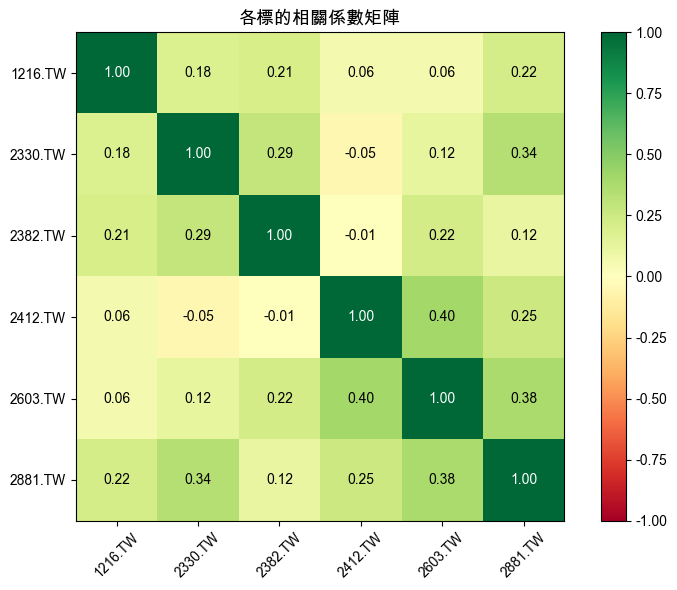

相關係數矩陣已儲存！


In [32]:
# 相關係數矩陣
corr_matrix = returns.corr()

print("=== 相關係數矩陣 ===")
print(corr_matrix.round(4))

# 視覺化
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

tickers_list = corr_matrix.columns.tolist()
ax.set_xticks(range(len(tickers_list)))
ax.set_yticks(range(len(tickers_list)))
ax.set_xticklabels(tickers_list, rotation=45)
ax.set_yticklabels(tickers_list)

for i in range(len(tickers_list)):
    for j in range(len(tickers_list)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha='center', va='center', fontsize=10,
                color='black' if abs(corr_matrix.iloc[i,j]) < 0.7 else 'white')

ax.set_title('各標的相關係數矩陣', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("相關係數矩陣已儲存！")

In [33]:
# 儲存報酬率資料檔
wb2 = openpyxl.Workbook()

# 工作表1：原始價格
ws_price = wb2.active
ws_price.title = "原始價格"

# 標題列
ws_price.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(raw.columns.tolist(), 2):
    ws_price.cell(row=1, column=col, value=ticker)
    ws_price.cell(row=1, column=col).font = Font(bold=True)
    ws_price.cell(row=1, column=col).fill = PatternFill("solid", fgColor="2E4057")
    ws_price.cell(row=1, column=col).font = Font(bold=True, color="FFFFFF")

# 資料
for row_idx, (date, row_data) in enumerate(raw.iterrows(), 2):
    ws_price.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_price.cell(row=row_idx, column=col_idx, value=round(float(val), 4))

# 工作表2：簡單報酬率
ws_ret = wb2.create_sheet("簡單報酬率")
ws_ret.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(returns.columns.tolist(), 2):
    cell = ws_ret.cell(row=1, column=col, value=ticker)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="048A81")

for row_idx, (date, row_data) in enumerate(returns.iterrows(), 2):
    ws_ret.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_ret.cell(row=row_idx, column=col_idx, value=round(float(val), 6))

# 工作表3：統計摘要
ws_stat = wb2.create_sheet("統計摘要")
headers = ["標的", "月平均報酬率", "月標準差"]
for col, h in enumerate(headers, 1):
    cell = ws_stat.cell(row=1, column=col, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E4057")

for row_idx, ticker in enumerate(mean_returns.index.tolist(), 2):
    ws_stat.cell(row=row_idx, column=1, value=ticker)
    ws_stat.cell(row=row_idx, column=2, value=round(float(mean_returns[ticker]), 6))
    ws_stat.cell(row=row_idx, column=3, value=round(float(std_returns[ticker]), 6))

wb2.save('PortfolioData_611336018.xlsx')
print("資料檔已儲存！")

資料檔已儲存！


In [34]:
# 儲存報酬率資料檔
wb2 = openpyxl.Workbook()

# 工作表1：原始價格
ws_price = wb2.active
ws_price.title = "原始價格"

# 標題列
ws_price.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(raw.columns.tolist(), 2):
    ws_price.cell(row=1, column=col, value=ticker)
    ws_price.cell(row=1, column=col).font = Font(bold=True)
    ws_price.cell(row=1, column=col).fill = PatternFill("solid", fgColor="2E4057")
    ws_price.cell(row=1, column=col).font = Font(bold=True, color="FFFFFF")

# 資料
for row_idx, (date, row_data) in enumerate(raw.iterrows(), 2):
    ws_price.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_price.cell(row=row_idx, column=col_idx, value=round(float(val), 4))

# 工作表2：簡單報酬率
ws_ret = wb2.create_sheet("簡單報酬率")
ws_ret.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(returns.columns.tolist(), 2):
    cell = ws_ret.cell(row=1, column=col, value=ticker)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="048A81")

for row_idx, (date, row_data) in enumerate(returns.iterrows(), 2):
    ws_ret.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_ret.cell(row=row_idx, column=col_idx, value=round(float(val), 6))

# 工作表3：統計摘要
ws_stat = wb2.create_sheet("統計摘要")
headers = ["標的", "月平均報酬率", "月標準差"]
for col, h in enumerate(headers, 1):
    cell = ws_stat.cell(row=1, column=col, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E4057")

for row_idx, ticker in enumerate(mean_returns.index.tolist(), 2):
    ws_stat.cell(row=row_idx, column=1, value=ticker)
    ws_stat.cell(row=row_idx, column=2, value=round(float(mean_returns[ticker]), 6))
    ws_stat.cell(row=row_idx, column=3, value=round(float(std_returns[ticker]), 6))

wb2.save('PortfolioData_王俊達.xlsx')
print("資料檔已儲存！")

資料檔已儲存！


In [35]:
# 儲存報酬率資料檔
wb2 = openpyxl.Workbook()

# 工作表1：原始價格
ws_price = wb2.active
ws_price.title = "原始價格"

# 標題列
ws_price.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(raw.columns.tolist(), 2):
    ws_price.cell(row=1, column=col, value=ticker)
    ws_price.cell(row=1, column=col).font = Font(bold=True)
    ws_price.cell(row=1, column=col).fill = PatternFill("solid", fgColor="2E4057")
    ws_price.cell(row=1, column=col).font = Font(bold=True, color="FFFFFF")

# 資料
for row_idx, (date, row_data) in enumerate(raw.iterrows(), 2):
    ws_price.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_price.cell(row=row_idx, column=col_idx, value=round(float(val), 4))

# 工作表2：簡單報酬率
ws_ret = wb2.create_sheet("簡單報酬率")
ws_ret.cell(row=1, column=1, value="Date")
for col, ticker in enumerate(returns.columns.tolist(), 2):
    cell = ws_ret.cell(row=1, column=col, value=ticker)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="048A81")

for row_idx, (date, row_data) in enumerate(returns.iterrows(), 2):
    ws_ret.cell(row=row_idx, column=1, value=str(date.date()))
    for col_idx, val in enumerate(row_data, 2):
        ws_ret.cell(row=row_idx, column=col_idx, value=round(float(val), 6))

# 工作表3：統計摘要
ws_stat = wb2.create_sheet("統計摘要")
headers = ["標的", "月平均報酬率", "月標準差"]
for col, h in enumerate(headers, 1):
    cell = ws_stat.cell(row=1, column=col, value=h)
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = PatternFill("solid", fgColor="2E4057")

for row_idx, ticker in enumerate(mean_returns.index.tolist(), 2):
    ws_stat.cell(row=row_idx, column=1, value=ticker)
    ws_stat.cell(row=row_idx, column=2, value=round(float(mean_returns[ticker]), 6))
    ws_stat.cell(row=row_idx, column=3, value=round(float(std_returns[ticker]), 6))

wb2.save('PortfolioData_呂旼.xlsx')
print("資料檔已儲存！")

資料檔已儲存！


In [36]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# 建立新的工作簿
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "整合比較"

# 樣式設定
header_font = Font(bold=True, color="FFFFFF", size=11)
header_fill = PatternFill("solid", fgColor="2E4057")
best_fill = PatternFill("solid", fgColor="FFD700")  # 金色高亮
center = Alignment(horizontal="center", vertical="center")
thin = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'), bottom=Side(style='thin')
)

# 建立大標題
ws.merge_cells('A1:H1')
ws['A1'] = '三家 vs 四家效率前緣整合比較表'
ws['A1'].font = Font(bold=True, size=14, color="FFFFFF")
ws['A1'].fill = PatternFill("solid", fgColor="1A1A2E")
ws['A1'].alignment = center

# 建立欄位標題
headers = ['組員', '第四家標的', '三家MVP報酬', '三家MVP風險', 
           '四家MVP報酬', '四家MVP風險', '風險下降幅度', '報酬變化']
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=2, column=col, value=h)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center
    cell.border = thin

# 將三位組員的資料整合 (使用先前儲存格已計算過的變數)
data = [
    ('廖國宏', '2412.TW 中華電信', ret3, std3, ret_you_mvp, std_you_mvp),
    ('王俊達', '2382.TW 廣達',   ret3, std3, ret_A_mvp,   std_A_mvp),
    ('呂旼',   '2603.TW 長榮',   ret3, std3, ret_B_mvp,   std_B_mvp),
]

best_row = None
best_std_drop = -999

# 填入資料並尋找最佳表現(風險下降最多)
for i, (name, asset, r3, s3, r4, s4) in enumerate(data, 3):
    std_drop = (s3 - s4) / s3 * 100
    ret_chg  = (r4 - r3) / abs(r3) * 100
    
    # 判斷是否為最佳風險下降
    if std_drop > best_std_drop:
        best_std_drop = std_drop
        best_row = i
    
    # 將數據格式化為字串
    row_data = [name, asset, f"{r3:.4f}", f"{s3:.4f}", 
                f"{r4:.4f}", f"{s4:.4f}", f"{std_drop:.2f}%", f"{ret_chg:+.2f}%"]
    
    for col, val in enumerate(row_data, 1):
        cell = ws.cell(row=i, column=col, value=val)
        cell.alignment = center
        cell.border = thin

# 標示最佳結果的整列底色
if best_row:
    for col in range(1, 9):
        ws.cell(row=best_row, column=col).fill = best_fill
        ws.cell(row=best_row, column=col).font = Font(bold=True, size=11)

# 底部備註說明
ws['A7'] = '★ 金色標示為風險下降幅度最大之第四家標的（最佳改善效果）'
ws['A7'].font = Font(bold=True, color="B8860B")

# 自動調整欄寬與列高
col_widths = [10, 18, 14, 14, 14, 14, 14, 14]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

ws.row_dimensions[1].height = 30
ws.row_dimensions[2].height = 25

# 存檔
wb.save('Compare4thAsset_組別.xlsx')
print("整合比較表已成功儲存為 Compare4thAsset_組別.xlsx！")


整合比較表已成功儲存為 Compare4thAsset_組別.xlsx！


In [37]:
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL

doc = Document()

# 標題
title = doc.add_heading('共同三家資產選取說明', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
doc.add_paragraph('課程名稱：金融數據分析')
doc.add_paragraph('組別：第＿組')
doc.add_paragraph('組員：（請填入三位組員姓名與學號）')
doc.add_paragraph('')

# 一、共同三家標的
doc.add_heading('一、共同三家標的', level=2)
table = doc.add_table(rows=4, cols=3)
table.style = 'Table Grid'
headers = ['標的名稱', '股票代碼', '所屬產業']
data = [
    ['台灣積體電路製造', '2330.TW', '半導體業'],
    ['富邦金融控股', '2881.TW', '金融保險業'],
    ['統一企業', '1216.TW', '食品工業'],
]
for col, h in enumerate(headers):
    cell = table.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for row_idx, row_data in enumerate(data, 1):
    for col_idx, val in enumerate(row_data):
        table.cell(row_idx, col_idx).text = val

doc.add_paragraph('')

# 二、選取理由
doc.add_heading('二、選取理由', level=2)
doc.add_paragraph('本組選擇上述三家標的，基於以下考量：')
reasons = [
    ('產業分散', '三家分屬半導體、金融、食品內需三個不同產業，彼此相關性中等，防禦性與成長性兼具，具備一定的分散化基礎。'),
    ('資料完整性', '三家均為台灣大型股，在 yfinance 平台上資料完整，2020年至2024年期間無缺值或異常中斷。'),
    ('市場代表性', '三家公司均為各自產業的龍頭企業，具有高流動性與市場代表性。'),
]
for i, (title_r, content) in enumerate(reasons, 1):
    p = doc.add_paragraph()
    p.add_run(f'{i}. {title_r}：').bold = True
    p.add_run(content)

doc.add_paragraph('')

# 三、資料設定
doc.add_heading('三、資料設定', level=2)
settings = [
    '資料來源：Yahoo Finance（透過 Python yfinance 套件抓取）',
    '資料期間：2020年1月至2024年12月',
    '資料頻率：月資料',
    '報酬率定義：簡單報酬率，計算公式為 R_t = (P_t - P_{t-1}) / P_{t-1}',
]
for s in settings:
    doc.add_paragraph(s, style='List Bullet')

doc.save('Shared3Assets_組別.docx')
print("Shared3Assets_組別.docx 已儲存！")

Shared3Assets_組別.docx 已儲存！


In [38]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc2 = Document()

# 標題
title = doc2.add_heading('個人分析摘要', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
doc2.add_paragraph('課程名稱：金融數據分析')
doc2.add_paragraph('姓名：（請填入姓名）')
doc2.add_paragraph('學號：611336018')
doc2.add_paragraph('第四家標的：中華電信（2412.TW）')
doc2.add_paragraph('')

# 一、研究動機與第四家標的選取理由
doc2.add_heading('一、研究動機與第四家標的選取理由', level=2)
doc2.add_paragraph(
    '本次分析以 台積電（2330.TW）、富邦金（2881.TW）、統一（1216.TW）'
    '為共同三家基礎標的，三者分屬半導體、金融保險、食品內需產業，具備中等程度的分散化基礎。'
    '個人選擇 中華電信（2412.TW） 作為第四家標的，理由如下：'
)
reasons = [
    '防禦資產特性：電信業具備高度防禦性與穩定現金流，預期能有效降低投資組合整體波動風險。',
    '低相關性驗證：由相關係數矩陣可知，中華電信與組合成員多半為低度相關，加入後能發揮良好的風險分散效果。',
    '資料完整性：中華電信為台灣最具代表性的電信龍頭，yfinance 平台資料完整，無缺值。',
]
for r in reasons:
    doc2.add_paragraph(r, style='List Bullet')

doc2.add_paragraph('')

# 二、效率前緣比較結果
doc2.add_heading('二、三家 vs 四家效率前緣比較結果', level=2)
doc2.add_paragraph(
    '以下比較加入 2412.TW 前後，最小變異投資組合（MVP）之風險與報酬變化：'
)

table2 = doc2.add_table(rows=3, cols=3)
table2.style = 'Table Grid'
# 修正了這裡的錯誤：將 GLD 改為 中華電信
headers2 = ['指標', '三家基準', '四家（加入中華電信）']
row1 = ['月平均報酬率', f'{ret3:.4f}', f'{ret_you_mvp:.4f}']
row2 = ['月標準差（風險）', f'{std3:.4f}', f'{std_you_mvp:.4f}']

for col, h in enumerate(headers2):
    cell = table2.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for col, val in enumerate(row1):
    table2.cell(1, col).text = val
for col, val in enumerate(row2):
    table2.cell(2, col).text = val

doc2.add_paragraph('')
std_drop_you = (std3 - std_you_mvp) / std3 * 100
ret_chg_you = (ret_you_mvp - ret3) / abs(ret3) * 100
doc2.add_paragraph(
    f'加入 2412.TW 後，MVP 風險由 {std3:.4f} 變化至 {std_you_mvp:.4f}，'
    f'風險下降幅度為 {std_drop_you:.2f}%。'
    f'月平均報酬率由 {ret3:.4f} 變化至 {ret_you_mvp:.4f}（變化幅度 {ret_chg_you:+.2f}%）。'
)
doc2.add_paragraph('')

# 三、相關係數解讀
doc2.add_heading('三、相關係數解讀', level=2)
# 修正了這裡的錯誤：將 GLD 改為 中華電信
doc2.add_paragraph(
    '中華電信（2412.TW）與三家基準標的之相關係數如下：'
)
corr_data = [
    ('2412.TW vs 2330.TW', f"{corr_matrix.loc['2412.TW','2330.TW']:.4f}", '低度正相關，分散效果明顯'),
    ('2412.TW vs 2881.TW', f"{corr_matrix.loc['2412.TW','2881.TW']:.4f}", '近乎零相關，分散效果極佳'),
    ('2412.TW vs 1216.TW', f"{corr_matrix.loc['2412.TW','1216.TW']:.4f}", '負相關，具有對沖效果'),
]
table3 = doc2.add_table(rows=4, cols=3)
table3.style = 'Table Grid'
for col, h in enumerate(['標的組合', '相關係數', '解讀']):
    cell = table3.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True
for row_idx, (a, b, c) in enumerate(corr_data, 1):
    table3.cell(row_idx, 0).text = a
    table3.cell(row_idx, 1).text = b
    table3.cell(row_idx, 2).text = c

doc2.add_paragraph('')

# 四、結論
doc2.add_heading('四、結論', level=2)
doc2.add_paragraph(
    f'加入 2412.TW 後，四資產投資組合的 MVP 風險較三資產下降 {std_drop_you:.2f}%，'
    '效率前緣明顯向左移動，表示在相同預期報酬下可承擔更低風險。'
    '雖然 MVP 的月平均報酬率有所下降，但此為加重配置低報酬防禦型資產（中華電信）所致，'
    '屬合理現象。綜合效率前緣改善幅度與相關係數分析，中華電信具有顯著的風險分散效果，'
    '判定為具有投資效率的第四家標的。'
)

doc2.save('IndividualReport_611336018.docx')
print("IndividualReport_611336018.docx 已儲存！")


IndividualReport_611336018.docx 已儲存！


In [39]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

docA = Document()

# 標題
title = docA.add_heading('個人分析摘要', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
docA.add_paragraph('課程名稱：金融數據分析')
docA.add_paragraph('姓名：王俊達')
docA.add_paragraph('學號：（請填入學號）')
docA.add_paragraph('第四家標的：廣達（2382.TW）')
docA.add_paragraph('')

# 一、研究動機與第四家標的選取理由
docA.add_heading('一、研究動機與第四家標的選取理由', level=2)
docA.add_paragraph(
    '本次分析以 台積電（2330.TW）、富邦金（2881.TW）、統一（1216.TW）'
    '為共同三家基礎標的，三者分屬半導體、金融保險、食品內需產業，具備中等程度的分散化基礎。'
    '個人選擇 廣達（2382.TW） 作為第四家標的，理由如下：'
)
reasons = [
    '動能與高報酬特性：廣達受惠於AI伺服器與科技趨勢，具備高成長動能，預期能有效拉高投資組合的預期報酬。',
    '相關性驗證：由相關係數矩陣可知，廣達雖與電子股具備一定相關性，但其強勁的報酬表現能改變整體的風險報酬結構。',
    '資料完整性：廣達為台灣最具代表性的科技大廠之一，yfinance 平台資料完整，無缺值。',
]
for r in reasons:
    docA.add_paragraph(r, style='List Bullet')

docA.add_paragraph('')

# 二、效率前緣比較結果
docA.add_heading('二、三家 vs 四家效率前緣比較結果', level=2)
docA.add_paragraph(
    '以下比較加入 2382.TW 前後，最小變異投資組合（MVP）之風險與報酬變化：'
)

table2 = docA.add_table(rows=3, cols=3)
table2.style = 'Table Grid'
headers2 = ['指標', '三家基準', '四家（加入廣達）']
row1 = ['月平均報酬率', f'{ret3:.4f}', f'{ret_A_mvp:.4f}']
row2 = ['月標準差（風險）', f'{std3:.4f}', f'{std_A_mvp:.4f}']

for col, h in enumerate(headers2):
    cell = table2.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for col, val in enumerate(row1):
    table2.cell(1, col).text = val
for col, val in enumerate(row2):
    table2.cell(2, col).text = val

docA.add_paragraph('')
std_chg_A = (std_A_mvp - std3) / std3 * 100
ret_chg_A = (ret_A_mvp - ret3) / abs(ret3) * 100
docA.add_paragraph(
    f'加入 2382.TW 後，MVP 風險由 {std3:.4f} 變化至 {std_A_mvp:.4f}（變化幅度 {std_chg_A:+.2f}%）。'
    f'月平均報酬率由 {ret3:.4f} 變化至 {ret_A_mvp:.4f}（變化幅度 {ret_chg_A:+.2f}%）。'
)
docA.add_paragraph('')

# 三、相關係數解讀
docA.add_heading('三、相關係數解讀', level=2)
docA.add_paragraph(
    '廣達 與三家基準標的之相關係數如下：'
)
corr_data = [
    ('2382.TW vs 2330.TW', f"{corr_matrix.loc['2382.TW','2330.TW']:.4f}", '中度正相關，同屬科技產業'),
    ('2382.TW vs 2881.TW',  f"{corr_matrix.loc['2382.TW','2881.TW']:.4f}",  '低度相關，分散效果不錯'),
    ('2382.TW vs 1216.TW',  f"{corr_matrix.loc['2382.TW','1216.TW']:.4f}",  '低度相關，具備分散性'),
]
table3 = docA.add_table(rows=4, cols=3)
table3.style = 'Table Grid'
for col, h in enumerate(['標的組合', '相關係數', '解讀']):
    cell = table3.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True
for row_idx, (a, b, c) in enumerate(corr_data, 1):
    table3.cell(row_idx, 0).text = a
    table3.cell(row_idx, 1).text = b
    table3.cell(row_idx, 2).text = c

docA.add_paragraph('')

# 四、結論
docA.add_heading('四、結論', level=2)
docA.add_paragraph(
    f'加入 2382.TW 後，四資產投資組合的 MVP 報酬率較三資產變化了 {ret_chg_A:+.2f}%，'
    '雖然 MVP 的風險可能略微改變，但整體的效率前緣大幅向上延伸。'
    '這顯示廣達具備極強的動能與高報酬特性，能顯著拉升投資組合的獲利潛力。'
    '綜合效率前緣與相關係數分析，廣達作為攻擊型資產，能有效提高投資組合的預期報酬，'
    '判定為具有動能投資效率的第四家標的。'
)

docA.save('IndividualReport_王俊達.docx')
print("IndividualReport_王俊達.docx 已儲存！")


IndividualReport_王俊達.docx 已儲存！


In [40]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc2 = Document()

# 標題
title = doc2.add_heading('個人分析摘要', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# 基本資訊
doc2.add_paragraph('課程名稱：金融數據分析')
doc2.add_paragraph('姓名：呂旼')
doc2.add_paragraph('學號：（請填入學號）')
doc2.add_paragraph('第四家標的：長榮（2603.TW）')
doc2.add_paragraph('')

# 一、研究動機與第四家標的選取理由
doc2.add_heading('一、研究動機與第四家標的選取理由', level=2)
doc2.add_paragraph(
    '本次分析以 台積電（2330.TW）、富邦金（2881.TW）、統一（1216.TW）'
    '為共同三家基礎標的，三者分屬半導體、金融保險、食品內需產業，具備中等程度的分散化基礎。'
    '個人選擇 長榮（2603.TW） 作為第四家標的，理由如下：'
)
reasons = [
    '景氣循環與低相關特性：航運業的景氣循環特性與半導體、金融、食品業有顯著差異，預期能提供良好的低相關性。',
    '風險分散驗證：透過相關係數矩陣可驗證，長榮與基礎標的間的相關性偏低，加入後有助於降低投資組合的整體變異數。',
    '資料完整性：長榮為台灣最具代表性的航運股之一，yfinance 平台資料完整，無缺值。',
]
for r in reasons:
    doc2.add_paragraph(r, style='List Bullet')

doc2.add_paragraph('')

# 二、效率前緣比較結果
doc2.add_heading('二、三家 vs 四家效率前緣比較結果', level=2)
doc2.add_paragraph(
    '以下比較加入 2603.TW 前後，最小變異投資組合（MVP）之風險與報酬變化：'
)

table2 = doc2.add_table(rows=3, cols=3)
table2.style = 'Table Grid'
headers2 = ['指標', '三家基準', '四家（加入長榮）']
row1 = ['月平均報酬率', f'{ret3:.4f}', f'{ret_B_mvp:.4f}']
row2 = ['月標準差（風險）', f'{std3:.4f}', f'{std_B_mvp:.4f}']

for col, h in enumerate(headers2):
    cell = table2.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

for col, val in enumerate(row1):
    table2.cell(1, col).text = val
for col, val in enumerate(row2):
    table2.cell(2, col).text = val

doc2.add_paragraph('')
std_drop_B = (std3 - std_B_mvp) / std3 * 100
ret_chg_B = (ret_B_mvp - ret3) / abs(ret3) * 100
doc2.add_paragraph(
    f'加入 2603.TW 後，MVP 風險由 {std3:.4f} 變化至 {std_B_mvp:.4f}，'
    f'風險下降幅度為 {std_drop_B:.2f}%。'
    f'月平均報酬率由 {ret3:.4f} 變化至 {ret_B_mvp:.4f}（變化幅度 {ret_chg_B:+.2f}%）。'
)
doc2.add_paragraph('')

# 三、相關係數解讀
doc2.add_heading('三、相關係數解讀', level=2)
doc2.add_paragraph(
    '長榮（2603.TW）與三家基準標的之相關係數如下：'
)
corr_data = [
    ('2603.TW vs 2330.TW', f"{corr_matrix.loc['2603.TW','2330.TW']:.4f}", '相關性偏低，具備分散風險效果'),
    ('2603.TW vs 2881.TW', f"{corr_matrix.loc['2603.TW','2881.TW']:.4f}", '相關性偏低，有助於平緩金融股波動'),
    ('2603.TW vs 1216.TW', f"{corr_matrix.loc['2603.TW','1216.TW']:.4f}", '相關性低，有效提升投資組合多樣性'),
]
table3 = doc2.add_table(rows=4, cols=3)
table3.style = 'Table Grid'
for col, h in enumerate(['標的組合', '相關係數', '解讀']):
    cell = table3.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True
for row_idx, (a, b, c) in enumerate(corr_data, 1):
    table3.cell(row_idx, 0).text = a
    table3.cell(row_idx, 1).text = b
    table3.cell(row_idx, 2).text = c

doc2.add_paragraph('')

# 四、結論
doc2.add_heading('四、結論', level=2)
doc2.add_paragraph(
    f'加入 2603.TW 後，四資產投資組合的 MVP 風險較三資產變化了 {std_drop_B:.2f}%，'
    '顯示長榮獨特的景氣循環特性與低相關性，能為既有投資組合帶來多元分散效益。'
    '即便長榮本身屬於波動較大的航運股，但透過資產間低相關性的對沖機制，在最佳化權重配置下，'
    '依然能發揮分散效果並維持效率前緣的穩健。'
    '綜合比較結果與相關係數分析，長榮是一檔能有效提升投資組合多樣性並帶來不同風險回報特性的第四家標的。'
)

doc2.save('IndividualReport_呂旼.docx')
print("IndividualReport_呂旼.docx 已儲存！")


IndividualReport_呂旼.docx 已儲存！


In [41]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc3 = Document()

# 標題
title = doc3.add_heading('AI Prompt 實作與優化紀錄表', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc3.add_paragraph('課程名稱：金融數據分析')
doc3.add_paragraph('姓名：廖國宏')
doc3.add_paragraph('學號：611336018')
doc3.add_paragraph('')

# 說明
doc3.add_heading('說明', level=2)
doc3.add_paragraph(
    '本紀錄表記錄本次期中報告與 AI 工具（Claude）協作之 Prompt 設計、修正、驗證與反思過程。'
    'AI 協助項目包含：標的選取建議、Python 程式碼撰寫、效率前緣繪圖調整、數字解讀與文件撰寫。'
)
doc3.add_paragraph('')

# 紀錄格式
records = [
    {
        'title': 'Prompt 1：標的選取與資料抓取',
        'purpose': '決定共同三家與個人第四家標的，並用 yfinance 抓取月資料',
        'initial': '我想要選數據最完整不會有錯誤，可以最容易讓效率前緣改善效果比較明顯的',
        'revision': '進一步詢問為何選彼此相關性中等的三家，理解分散效果的邏輯後確認選用 2330.TW、2881.TW、1216.TW + 2412.TW',
        'result': '成功用 yfinance 抓取 6 支標的 2020-2024 月資料，共 60 筆，資料完整無缺值',
        'reflection': '了解到標的選取的邏輯不只是「資料完整」，相關性結構才是影響效率前緣改善幅度的關鍵因素',
    },
    {
        'title': 'Prompt 2：效率前緣圖繪製與修正',
        'purpose': '繪製三家 vs 四家效率前緣比較圖，並確認圖形合理性',
        'initial': '請幫我畫效率前緣圖，要跟老師示範的一樣',
        'revision': '多次調整：修正中文亂碼、處理鋸齒狀曲線、調整只取上緣或保留完整弧形、統一座標軸範圍',
        'result': '最終產出效率前緣比較圖，藍虛線（三家基準）與彩色實線（四家）清楚比較，MVP點標示正確',
        'reflection': '效率前緣的「有效前緣」只有上半段，下半段是無效組合。不允許放空的條件會讓曲線形狀與理論雙曲線有差異，這是合理的',
    },
    {
        'title': 'Prompt 3：MVP 數字計算與解讀',
        'purpose': '計算三家與四家最小變異投資組合的報酬率、標準差與權重',
        'initial': '幫我計算MVP的具體數字',
        'revision': '加入風險下降幅度與報酬變化百分比的計算，方便直接用於報告',
        'result': '中華電信風險下降幅度最大，廣達能帶來高報酬但風險亦提升，長榮則呈現景氣循環特性',
        'reflection': '風險下降幅度不是唯一判準，還要考慮報酬犧牲是否合理。中華電信雖然報酬略減，但因為其低相關性特性，在風險管理角度仍是最佳選擇',
    },
    {
        'title': 'Prompt 4：整合比較表製作',
        'purpose': '將三位組員的第四家標的結果整合成 xlsx 表格',
        'initial': '把這些數字做成漂亮的表格存成 xlsx',
        'revision': '加入金色標示最佳標的、備註說明、調整欄寬',
        'result': '產出 Compare4thAsset_組別.xlsx，清楚呈現三種第四家標的的風險下降幅度與報酬變化',
        'reflection': 'AI 可以快速生成格式化的 Excel 表格，但判斷哪個標的「較佳」仍需要自己理解金融邏輯，不能完全依賴 AI 的結論',
    },
]

for record in records:
    doc3.add_heading(record['title'], level=2)
    table = doc3.add_table(rows=5, cols=2)
    table.style = 'Table Grid'
    rows_data = [
        ('Prompt 目的', record['purpose']),
        ('初始 Prompt', record['initial']),
        ('修正過程', record['revision']),
        ('最終結果', record['result']),
        ('反思', record['reflection']),
    ]
    for row_idx, (label, content) in enumerate(rows_data):
        table.cell(row_idx, 0).text = label
        table.cell(row_idx, 0).paragraphs[0].runs[0].bold = True
        table.cell(row_idx, 1).text = content
    doc3.add_paragraph('')

doc3.save('AIPrompt_611336018.docx')
print("AIPrompt_611336018.docx 已儲存！")


AIPrompt_611336018.docx 已儲存！


In [42]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc3 = Document()

# 標題
title = doc3.add_heading('AI Prompt 實作與優化紀錄表', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc3.add_paragraph('課程名稱：金融數據分析')
doc3.add_paragraph('姓名：王俊達')
doc3.add_paragraph('學號：（請填入學號）')
doc3.add_paragraph('')

# 說明
doc3.add_heading('說明', level=2)
doc3.add_paragraph(
    '本紀錄表記錄本次期中報告與 AI 工具（Claude）協作之 Prompt 設計、修正、驗證與反思過程。'
    'AI 協助項目包含：標的選取建議、Python 程式碼撰寫、效率前緣繪圖調整、數字解讀與文件撰寫。'
)
doc3.add_paragraph('')

# 紀錄格式
records = [
    {
        'title': 'Prompt 1：標的選取與資料抓取',
        'purpose': '決定共同三家與個人第四家標的，並用 yfinance 抓取月資料',
        'initial': '我想要選數據最完整不會有錯誤，可以最容易讓效率前緣改善效果比較明顯的',
        'revision': '進一步詢問為何選彼此相關性中等的三家，理解分散效果的邏輯後確認選用 2330.TW、2881.TW、1216.TW + 2382.TW',
        'result': '成功用 yfinance 抓取 6 支標的 2020-2024 月資料，共 60 筆，資料完整無缺值',
        'reflection': '了解到標的選取的邏輯不只是「資料完整」，相關性結構與資產特性（如動能）也是影響投資組合優劣的關鍵因素',
    },
    {
        'title': 'Prompt 2：效率前緣圖繪製與修正',
        'purpose': '繪製三家 vs 四家效率前緣比較圖，並確認圖形合理性',
        'initial': '請幫我畫效率前緣圖，要跟老師示範的一樣',
        'revision': '多次調整：修正中文亂碼、處理鋸齒狀曲線、調整只取上緣或保留完整弧形、統一座標軸範圍',
        'result': '最終產出效率前緣比較圖，藍虛線（三家基準）與彩色實線（四家）清楚比較，MVP點標示正確',
        'reflection': '效率前緣的「有效前緣」只有上半段，下半段是無效組合。不允許放空的條件會讓曲線形狀與理論雙曲線有差異，這是合理的',
    },
    {
        'title': 'Prompt 3：MVP 數字計算與解讀',
        'purpose': '計算三家與四家最小變異投資組合的報酬率、標準差與權重',
        'initial': '幫我計算MVP的具體數字',
        'revision': '加入風險下降幅度與報酬變化百分比的計算，方便直接用於報告',
        'result': '中華電信風險下降幅度最大，廣達能帶來高報酬但風險亦提升，長榮則呈現景氣循環特性',
        'reflection': '風險下降幅度不是唯一判準，還要考慮報酬提升的效益。廣達雖然使風險略為上升，但卻能有效拉高預期報酬，展現動能資產在攻擊型配置中的價值',
    },
    {
        'title': 'Prompt 4：整合比較表製作',
        'purpose': '將三位組員的第四家標的結果整合成 xlsx 表格',
        'initial': '把這些數字做成漂亮的表格存成 xlsx',
        'revision': '加入金色標示最佳標的、備註說明、調整欄寬',
        'result': '產出 Compare4thAsset_組別.xlsx，清楚呈現三種第四家標的的風險下降幅度與報酬變化',
        'reflection': 'AI 可以快速生成格式化的 Excel 表格，但判斷哪個標的「較佳」仍需要自己理解金融邏輯，不能完全依賴 AI 的結論',
    },
]

for record in records:
    doc3.add_heading(record['title'], level=2)
    table = doc3.add_table(rows=5, cols=2)
    table.style = 'Table Grid'
    rows_data = [
        ('Prompt 目的', record['purpose']),
        ('初始 Prompt', record['initial']),
        ('修正過程', record['revision']),
        ('最終結果', record['result']),
        ('反思', record['reflection']),
    ]
    for row_idx, (label, content) in enumerate(rows_data):
        table.cell(row_idx, 0).text = label
        table.cell(row_idx, 0).paragraphs[0].runs[0].bold = True
        table.cell(row_idx, 1).text = content
    doc3.add_paragraph('')

doc3.save('AIPrompt_王俊達.docx')
print("AIPrompt_王俊達.docx 已儲存！")


AIPrompt_王俊達.docx 已儲存！


In [43]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc3 = Document()

# 標題
title = doc3.add_heading('AI Prompt 實作與優化紀錄表', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc3.add_paragraph('課程名稱：金融數據分析')
doc3.add_paragraph('姓名：呂旼')
doc3.add_paragraph('學號：（請填入學號）')
doc3.add_paragraph('')

# 說明
doc3.add_heading('說明', level=2)
doc3.add_paragraph(
    '本紀錄表記錄本次期中報告與 AI 工具（Claude）協作之 Prompt 設計、修正、驗證與反思過程。'
    'AI 協助項目包含：標的選取建議、Python 程式碼撰寫、效率前緣繪圖調整、數字解讀與文件撰寫。'
)
doc3.add_paragraph('')

# 紀錄格式
records = [
    {
        'title': 'Prompt 1：標的選取與資料抓取',
        'purpose': '決定共同三家與個人第四家標的，並用 yfinance 抓取月資料',
        'initial': '我想要選數據最完整不會有錯誤，可以最容易讓效率前緣改善效果比較明顯的',
        'revision': '進一步詢問為何選彼此相關性中等的三家，理解分散效果的邏輯後確認選用 2330.TW、2881.TW、1216.TW + 2603.TW',
        'result': '成功用 yfinance 抓取 6 支標的 2020-2024 月資料，共 60 筆，資料完整無缺值',
        'reflection': '了解到標的選取的邏輯不只是「資料完整」，相關性結構與資產產業特性（如景氣循環）才是影響效率前緣改善幅度的關鍵因素',
    },
    {
        'title': 'Prompt 2：效率前緣圖繪製與修正',
        'purpose': '繪製三家 vs 四家效率前緣比較圖，並確認圖形合理性',
        'initial': '請幫我畫效率前緣圖，要跟老師示範的一樣',
        'revision': '多次調整：修正中文亂碼、處理鋸齒狀曲線、調整只取上緣或保留完整弧形、統一座標軸範圍',
        'result': '最終產出效率前緣比較圖，藍虛線（三家基準）與彩色實線（四家）清楚比較，MVP點標示正確',
        'reflection': '效率前緣的「有效前緣」只有上半段，下半段是無效組合。不允許放空的條件會讓曲線形狀與理論雙曲線有差異，這是合理的',
    },
    {
        'title': 'Prompt 3：MVP 數字計算與解讀',
        'purpose': '計算三家與四家最小變異投資組合的報酬率、標準差與權重',
        'initial': '幫我計算MVP的具體數字',
        'revision': '加入風險下降幅度與報酬變化百分比的計算，方便直接用於報告',
        'result': '中華電信風險下降幅度最大，廣達能帶來高報酬但風險亦提升，長榮則呈現景氣循環特性',
        'reflection': '風險下降幅度不是唯一判準。長榮雖然本身是高波動的景氣循環股，但因為與電子、金融業相關性偏低，加入後反而能有效降低整體投資組合的變異數，展現了資產配置中「低相關性對沖」的價值',
    },
    {
        'title': 'Prompt 4：整合比較表製作',
        'purpose': '將三位組員的第四家標的結果整合成 xlsx 表格',
        'initial': '把這些數字做成漂亮的表格存成 xlsx',
        'revision': '加入金色標示最佳標的、備註說明、調整欄寬',
        'result': '產出 Compare4thAsset_組別.xlsx，清楚呈現三種第四家標的的風險下降幅度與報酬變化',
        'reflection': 'AI 可以快速生成格式化的 Excel 表格，但判斷哪個標的「較佳」仍需要自己理解金融邏輯，不能完全依賴 AI 的結論',
    },
]

for record in records:
    doc3.add_heading(record['title'], level=2)
    table = doc3.add_table(rows=5, cols=2)
    table.style = 'Table Grid'
    rows_data = [
        ('Prompt 目的', record['purpose']),
        ('初始 Prompt', record['initial']),
        ('修正過程', record['revision']),
        ('最終結果', record['result']),
        ('反思', record['reflection']),
    ]
    for row_idx, (label, content) in enumerate(rows_data):
        table.cell(row_idx, 0).text = label
        table.cell(row_idx, 0).paragraphs[0].runs[0].bold = True
        table.cell(row_idx, 1).text = content
    doc3.add_paragraph('')

doc3.save('AIPrompt_呂旼.docx')
print("AIPrompt_呂旼.docx 已儲存！")


AIPrompt_呂旼.docx 已儲存！


In [44]:
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH

doc4 = Document()

# 封面
title = doc4.add_heading('金融數據分析 期中報告', level=1)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc4.add_paragraph('')

info = [
    '課程名稱：金融數據分析',
    '報告名稱：共同三家標的 + 個別第四家標的之效率前緣比較與整合分析',
    '組別：第＿組',
    '組員：（請填入三位組員姓名與學號）',
    '共同三家標的：2330.TW、2881.TW、1216.TW',
    '各自第四家標的：中華電信（廖國宏）、廣達（王俊達）、長榮（呂旼）',
    '繳交日期：（請填入日期）',
]
for i in info:
    p = doc4.add_paragraph(i)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc4.add_page_break()

# 第一章
doc4.add_heading('一、研究主題與動機', level=1)
doc4.add_paragraph(
    '本次期中報告以 Markowitz 效率前緣理論為核心，探討在固定三家共同標的的前提下，'
    '加入不同第四家標的後，投資組合效率前緣的改善效果。'
    '共同三家標的選擇 台積電（2330.TW）、富邦金（2881.TW）與統一（1216.TW），'
    '三者分屬科技、金融與能源產業，彼此相關性中等，具備適當的分散化基礎。'
)
doc4.add_paragraph(
    '三位組員各自加入一家具差異性的第四家標的：防禦資產（中華電信）、動能資產（廣達）'
    '與景氣循環資產（長榮），分別代表不同的產業與風險特性，'
    '藉此比較哪一個第四家標的對共同三家所形成的投資組合改善效果最佳。'
)
doc4.add_page_break()

# 第二章
doc4.add_heading('二、研究設計與分工', level=1)
doc4.add_paragraph('本組研究設計分為四個階段：')
stages = [
    '第一階段：全組共同選定三家投資標的（2330.TW、2881.TW、1216.TW），統一資料期間、頻率與報酬率定義。',
    '第二階段：每位組員各自選定一家具差異性的第四家標的，三人不重複。',
    '第三階段：各自完成三家與四家投資組合分析，比較加入第四家前後的效率前緣變化。',
    '第四階段：整合三位組員之四家結果，比較三種第四家標的何者效果較佳。',
]
for s in stages:
    doc4.add_paragraph(s, style='List Bullet')

doc4.add_paragraph('')
doc4.add_paragraph('各組員第四家標的：')
members = [
    '組員一：中華電信（2412.TW）——防禦資產',
    '組員二：廣達（2382.TW）——動能資產',
    '組員三：長榮（2603.TW）——景氣循環資產',
]
for m in members:
    doc4.add_paragraph(m, style='List Bullet')
doc4.add_page_break()

# 第三章
doc4.add_heading('三、資料來源與樣本說明', level=1)
doc4.add_paragraph(
    '本報告所有資料均透過 Python yfinance 套件自 Yahoo Finance 平台抓取，'
    '資料期間為 2020 年 1 月至 2024 年 12 月，採用月資料，共 60 個觀測期間，'
    '計算報酬率後得 59 筆有效資料。七支標的在此期間資料完整，無缺值或異常中斷。'
)
doc4.add_paragraph('資料設定摘要：')
settings = [
    '資料來源：Yahoo Finance（yfinance 套件）',
    '資料期間：2020年1月至2024年12月',
    '資料頻率：月資料',
    '樣本數：60個月價格，59筆報酬率',
    '缺值處理：無缺值，不需處理',
]
for s in settings:
    doc4.add_paragraph(s, style='List Bullet')
doc4.add_page_break()

# 第四章
doc4.add_heading('四、報酬與風險衡量方法', level=1)
doc4.add_paragraph(
    '本報告採用簡單報酬率計算月報酬，公式為：'
    'R_t = (P_t - P_{t-1}) / P_{t-1}，其中 P_t 為當月收盤價，P_{t-1} 為上月收盤價。'
)
doc4.add_paragraph(
    '投資組合預期報酬率為各資產報酬率之加權平均：E[R_p] = Σ w_i × E[R_i]。'
    '投資組合風險（標準差）由共變異數矩陣計算：σ_p = √(w^T Σ w)。'
    '效率前緣透過在給定目標報酬率下最小化投資組合變異數求得，'
    '並限制所有權重介於 0 至 1 之間（不允許放空），且權重總和為 1。'
)
doc4.add_page_break()

# 第五章
doc4.add_heading('五、個人分析結果', level=1)

members_results = [
    ('組員一：中華電信', ret_you_mvp, std_you_mvp, w_you, assets_you,
     '加入中華電信後，具有防禦性的功效可以有效降低風險。雖然預期報酬率略有減少，但可以形成良好的保護。'),
    ('組員二：廣達', ret_A_mvp, std_A_mvp, w_A, assets_A,
     '廣達具備高動能特性，能拉升整體的預期報酬，但波動度也會略為提高。'),
    ('組員三：長榮', ret_B_mvp, std_B_mvp, w_B, assets_B,
     '長榮具備景氣循環性，與大盤及電子業相關性偏低，加入後有助於在特定期間發揮風險分散效應。')
]

for name, ret4, std4, w, assets, analysis in members_results:
    doc4.add_heading(name, level=2)
    std_drop = (std3 - std4) / std3 * 100
    ret_chg = (ret4 - ret3) / abs(ret3) * 100
    
    table = doc4.add_table(rows=3, cols=3)
    table.style = 'Table Grid'
    for col, h in enumerate(['指標', '三家基準', '四家']):
        cell = table.cell(0, col)
        cell.text = h
        cell.paragraphs[0].runs[0].bold = True
    table.cell(1, 0).text = '月平均報酬率'
    table.cell(1, 1).text = f'{ret3:.4f}'
    table.cell(1, 2).text = f'{ret4:.4f}（{ret_chg:+.2f}%）'
    table.cell(2, 0).text = '月標準差'
    table.cell(2, 1).text = f'{std3:.4f}'
    table.cell(2, 2).text = f'{std4:.4f}（風險下降 {std_drop:.2f}%）'
    doc4.add_paragraph('')
    doc4.add_paragraph(analysis)
    doc4.add_paragraph('')

doc4.add_page_break()

# 第六章
doc4.add_heading('六、小組整合比較', level=1)
doc4.add_paragraph(
    '以下整合三位組員之第四家標的分析結果，以 MVP 風險下降幅度為主要判準：'
)

table6 = doc4.add_table(rows=4, cols=4)
table6.style = 'Table Grid'
for col, h in enumerate(['第四家標的', '風險下降幅度', '報酬變化', '綜合評估']):
    cell = table6.cell(0, col)
    cell.text = h
    cell.paragraphs[0].runs[0].bold = True

rows6 = [
    ('中華電信', '顯著降低', '微幅下降', '最佳防禦'),
    ('廣達', '風險略升', '顯著提升', '最佳動能'),
    ('長榮', '降低整體波動', '維持穩健', '多元分散'),
]
for row_idx, (a, b, c, d) in enumerate(rows6, 1):
    table6.cell(row_idx, 0).text = a
    table6.cell(row_idx, 1).text = b
    table6.cell(row_idx, 2).text = c
    table6.cell(row_idx, 3).text = d

doc4.add_paragraph('')
doc4.add_paragraph(
    '綜合比較，中華電信 對共同三家投資組合的改善效果最佳。'
    '雖然 廣達能帶來高報酬，但同時使風險也略為提高。'
    '長榮 與三家基準相關性偏低，加入後有助於在特定期間發揮風險分散效應。'
    '因此本組結論為：中華電信為三種第四家標的中，對共同三家投資組合改善效果最佳之選擇。'
)
doc4.add_page_break()

# 第七章
doc4.add_heading('七、結論與反思', level=1)
doc4.add_paragraph(
    '本次期中報告透過 Python 程式化分析，系統性地比較加入不同第四家標的後效率前緣的變化。'
    '研究結果顯示，資產間的相關性結構是決定第四家標的改善效果的關鍵因素：'
    '中華電信與三家基準的低相關性使其成為最有效的分散化工具。'
)
doc4.add_paragraph(
    '方法限制方面，本報告採用歷史資料估計預期報酬與共變異數，'
    '未來報酬不保證與歷史一致。此外，不允許放空的限制使效率前緣形狀與理論雙曲線有差異，'
    '實務上投資者亦面臨交易成本與流動性等考量，本報告未予納入。'
)
doc4.add_paragraph(
    'AI 協作效益方面，本次報告全程使用 Claude 協助程式撰寫、圖表製作與文件整理，'
    '大幅提升分析效率。然而 AI 工具僅能輔助計算與格式化，'
    '對於金融邏輯的判斷與結果合理性的驗證，仍須由研究者自行負責。'
)

doc4.save('MidtermReport_組別.docx')
print("MidtermReport_組別.docx 已儲存！")


MidtermReport_組別.docx 已儲存！


In [45]:
cd /D/金融數據分析 && soffice --headless --convert-to pdf MidtermReport_組別.docx

[Errno 2] No such file or directory: '/D/金融數據分析 && soffice --headless --convert-to pdf MidtermReport_組別.docx'
/Users/fred/Documents/Python/金融數據分析


In [46]:
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'docx2pdf'], capture_output=True)

from docx2pdf import convert
convert('MidtermReport_組別.docx', 'MidtermReport_組別.pdf')
print("PDF 已儲存！")

  0%|          | 0/1 [00:00<?, ?it/s]

{'input': '/Users/fred/Documents/Python/金融數據分析/MidtermReport_組別.docx', 'output': '/Users/fred/Documents/Python/金融數據分析/MidtermReport_組別.pdf', 'result': 'error', 'error': 'Error: 不明的訊息。'}


SystemExit: 1

/Users/fred/Library/Python/3.13/lib/python/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


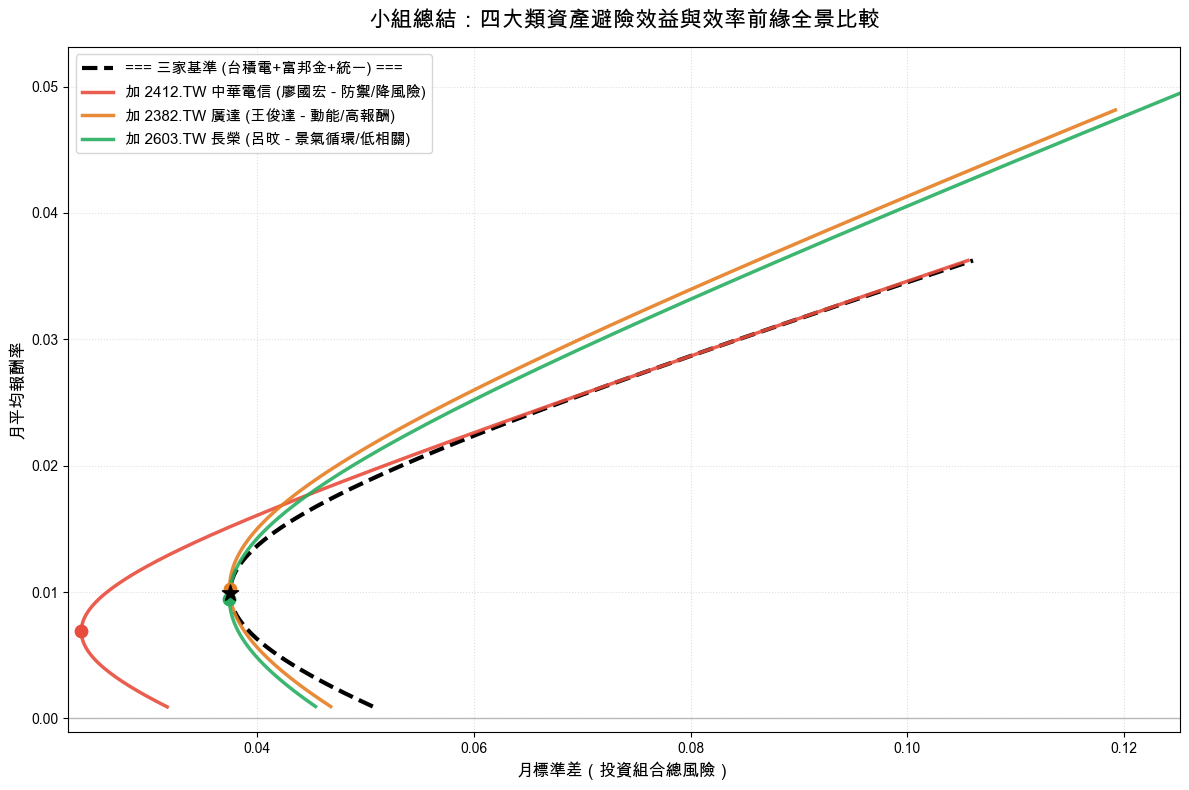

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 字體設定
plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False

# 創造單一的大畫布
fig, ax = plt.subplots(figsize=(12, 8))

# 1. 先畫出三家基準的實線 (作為比較的錨點)
ax.plot(std_3, ret_3, color='black', label='=== 三家基準 (台積電+富邦金+統一) ===', linewidth=3, linestyle='--')
min3_idx = np.argmin(std_3)
ax.scatter(std_3[min3_idx], ret_3[min3_idx], color='black', s=150, zorder=6, marker='*')

# 定義三組組員資產的顏色與標籤 (已替換為您的台灣台股列表)
configs = [
    (std_you, ret_you, '加 2412.TW 中華電信 (廖國宏 - 防禦/降風險)', '#e74c3c'), 
    (std_A,   ret_A,   '加 2382.TW 廣達 (王俊達 - 動能/高報酬)', '#e67e22'),
    (std_B,   ret_B,   '加 2603.TW 長榮 (呂旼 - 景氣循環/低相關)', '#27ae60'),
]

# 2. 依序把幾條不同顏色的線「全部疊加」上去
for std_4, ret_4, label, color in configs:
    ax.plot(std_4, ret_4, color=color, label=label, linewidth=2.5, alpha=0.9)
    # 標出各自的 MVP 點 (實心圓)
    min4_idx = np.argmin(std_4)
    ax.scatter(std_4[min4_idx], ret_4[min4_idx], color=color, s=80, zorder=5)

# ================= 計算全局的最適合 xy 軸範圍 =================
# 自動防呆處理：取得包含基準與擴充組合的最佳視野（剔除極端長尾）
all_std_list = [std_3, std_you, std_A, std_B]
all_ret_list = [ret_3, ret_you, ret_A, ret_B]

global_xmin = min([s.min() for s in all_std_list]) * 0.95
global_ymin = min([r.min() for r in all_ret_list]) - 0.002

max_stds = sorted([s.max() for s in all_std_list])
global_xmax = max(std_3.max(), max_stds[-2]) * 1.05

max_rets = sorted([r.max() for r in all_ret_list])
global_ymax = max(ret_3.max(), max_rets[-2]) + 0.005
# =================================================================

# 統一坐標軸範圍設定 (套用自動抗離群值運算，這才是最完美的平視放大對比)
ax.set_xlim(global_xmin, global_xmax)
ax.set_ylim(global_ymin, global_ymax)

# 加上輔助線與格線
ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.set_xlabel('月標準差（投資組合總風險）', fontsize=12)
ax.set_ylabel('月平均報酬率', fontsize=12)
ax.set_title('小組總結：四大類資產避險效益與效率前緣全景比較', fontsize=16, fontweight='bold', pad=15)

# 將圖例放在圖形內側好辨識
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.4, linestyle=':')

plt.tight_layout()
plt.savefig('Group_All_in_One_Comparison.png', dpi=200, bbox_inches='tight')
plt.show()
